# Week 5: The Forger. Analysis notebook

Can a detector built only from week 5 tools (counts, hapaxes, n-grams, Bag of Words) tell Claude Fable 5.1's forged
Wikipedia articles from the real ones? This notebook covers **round 1** (no feedback to the forger).

Everything here is computed by `pipeline/03_features.py` and `pipeline/04_detector.py`; the notebook loads their
outputs, draws the figures and prints the texts we read by hand. **Every text marked "forgery" below is AI-generated.**
Real article text is from Wikipedia, CC BY-SA 4.0.

## Preprocessing choices (one set, used for every document)

| Step | Choice |
|---|---|
| Cleaning | `pipeline/cleaning.py`, the same function for real pages and forgeries: reference / link-list sections dropped, headings unified to `== Heading ==`, quotes normalised |
| Comparison text | real: first ≤1500 words of the cleaned page, cut at a paragraph boundary; forged: the whole cleaned forgery (written to the same target length) |
| What is analysed | prose paragraphs only; heading lines are dropped |
| Tokens | lowercase runs of letters/digits, one internal apostrophe kept (`doom's`); hyphens split words; punctuation is not a token |
| Bigrams | adjacent tokens inside one paragraph |
| Sentences | split at `. ! ?` + space + capital/digit/quote, not after common abbreviations or single initials; paragraph end = sentence end |
| Stopwords | NLTK English list (198 words) |
| Length control | type/token and hapax ratio on non-overlapping 400-token windows, averaged (Heaps' law: raw ratios fall with length) |
| Leave-one-out | "never-seen bigrams" and "similarity to all real articles" use the other 302 real pages, never the character's own page, for real and forged documents alike |
| Neighbours | union of in- and out-links in the week 1 network; Captain Midlands and Sean and Chris have none, so that feature is imputed with the training median |

In [1]:
import sys, json, importlib
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT / 'pipeline'))
import config, textstats as ts
pd.set_option('display.width', 160)

REAL, FORGED = '#2a78d6', '#eb6834'          # validated categorical slots 1-2 (blue = real, orange = forged)
INK, MUTED, GRID = '#0b0b0b', '#52514e', '#e6e5e0'
plt.rcParams.update({'figure.facecolor': '#fcfcfb', 'axes.facecolor': '#fcfcfb', 'axes.edgecolor': GRID,
                     'axes.labelcolor': MUTED, 'xtick.color': MUTED, 'ytick.color': MUTED, 'text.color': INK,
                     'axes.spines.top': False, 'axes.spines.right': False, 'font.size': 10})
FIG = ROOT / 'figures'; FIG.mkdir(exist_ok=True)

feat = pd.read_csv(ROOT / 'outputs/features.csv')
r1 = feat[feat['round'].isin([0, 1])].reset_index(drop=True)
res = json.loads((ROOT / 'outputs/detector_D1.json').read_text())
pred = pd.read_csv(ROOT / 'outputs/predictions_D1.csv')
print(f"{len(r1)} documents: {(r1.label==0).sum()} real, {(r1.label==1).sum()} forged (round 1)")

120 documents: 60 real, 60 forged (round 1)


## 1. Real vs forged, feature by feature

In [2]:
summary = r1.groupby('label')[ts.FEATURES].median().T.rename(columns={0: 'real (median)', 1: 'forged (median)'})
summary['one-feature AUC'] = [res['single_feature'][f]['auc'] for f in summary.index]
summary.index = [ts.FEATURE_LABELS[f] for f in summary.index]
summary.sort_values('one-feature AUC', ascending=False).round(3)

label,real (median),forged (median),one-feature AUC
mean sentence length (tokens),20.079,24.491,0.841
parentheses per 100 tokens,0.611,1.047,0.725
share of word pairs never seen in real articles,0.321,0.280,0.705
hapax ratio (per 400-token window),0.396,0.415,0.673
dashes per 100 tokens,0.115,0.361,0.659
word-use similarity to linked characters' articles,0.419,0.469,0.641
word-use similarity to all real articles,0.332,0.366,0.616
type/token ratio (per 400-token window),0.534,0.547,0.610
commas per 100 tokens,5.782,5.485,0.541
stopword share,0.404,0.407,0.527


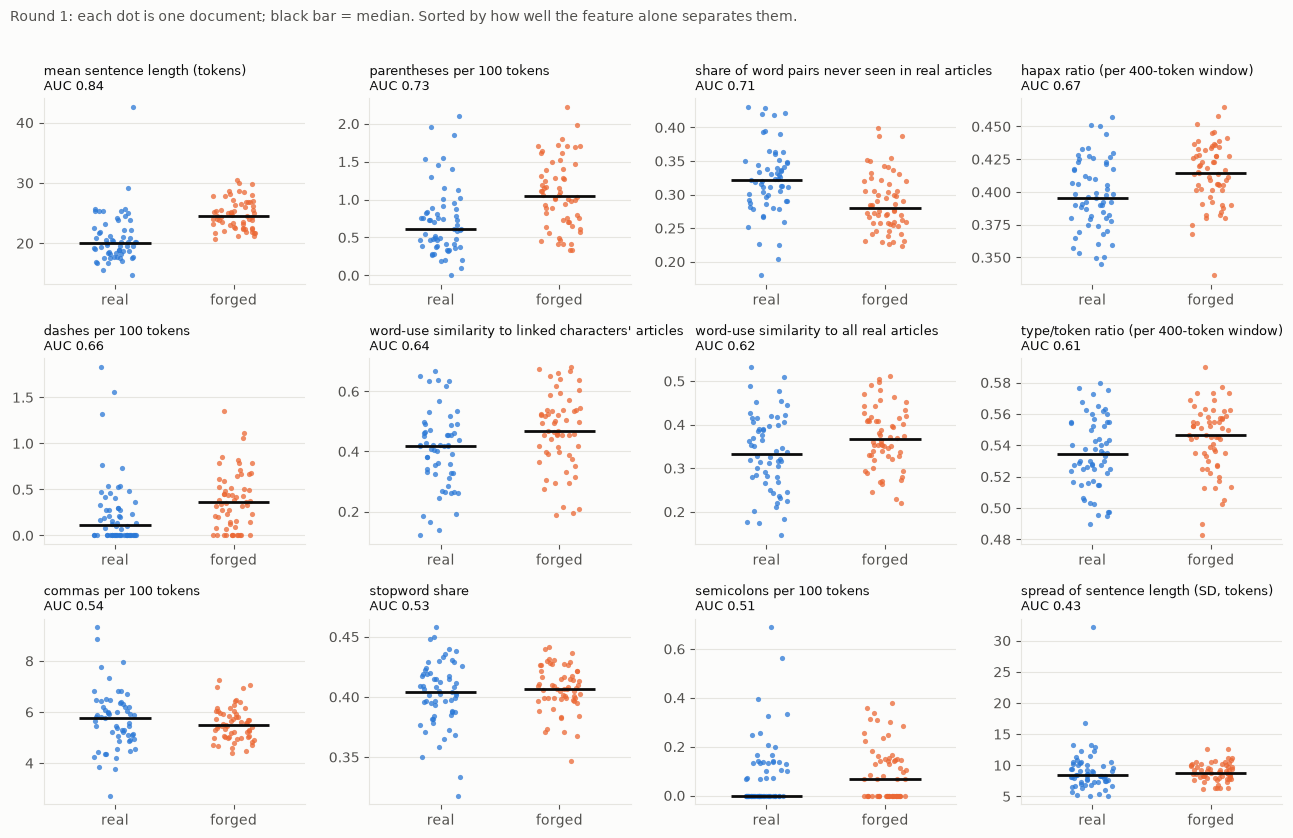

In [3]:
order = sorted(ts.FEATURES, key=lambda f: -res['single_feature'][f]['auc'])
fig, axes = plt.subplots(3, 4, figsize=(13, 8.5))
rng = np.random.default_rng(0)
for ax, f in zip(axes.flat, order):
    for k, (lab, col) in enumerate([(0, REAL), (1, FORGED)]):
        v = r1.loc[r1.label == lab, f].dropna().values
        ax.scatter(k + rng.uniform(-0.18, 0.18, len(v)), v, s=14, color=col, alpha=0.75, linewidths=0)
        ax.hlines(np.median(v), k - 0.3, k + 0.3, color=INK, lw=2)
    ax.set_xticks([0, 1], ['real', 'forged'])
    ax.set_xlim(-0.6, 1.6)
    ax.set_title(f"{ts.FEATURE_LABELS[f]}\nAUC {res['single_feature'][f]['auc']:.2f}", fontsize=9, loc='left')
    ax.grid(axis='y', color=GRID, lw=0.8); ax.set_axisbelow(True)
fig.suptitle('Round 1: each dot is one document; black bar = median. Sorted by how well the feature alone separates them.',
             fontsize=10, x=0.01, ha='left', color=MUTED)
fig.tight_layout(rect=(0, 0, 1, 0.97))
for ext in ('png', 'svg'): fig.savefig(FIG / f'feature_distributions_round1.{ext}', dpi=150)
plt.show()

## 2. Detector D1: standardized features + logistic regression

10-fold cross-validation **grouped by character**: a character's real page and its forgery are always in the same fold, so the detector never sees the real page of a character it is tested on. *Pair accuracy* is the game's question: given both pages for one character, does the forgery get the higher P(forged)?

In [4]:
cv = res['cv']
print(f"D1 (all 12 features): accuracy {cv['accuracy']:.1%}   AUC {cv['auc']:.3f}   pair accuracy {cv['pair_accuracy']:.1%}")
single = pd.DataFrame(res['single_feature']).T.sort_values('auc', ascending=False)
single.index = [ts.FEATURE_LABELS[f] for f in single.index]
single.round(3)

D1 (all 12 features): accuracy 88.3%   AUC 0.932   pair accuracy 96.7%


,accuracy,auc,pair_accuracy
mean sentence length (tokens),0.750,0.841,0.933
parentheses per 100 tokens,0.700,0.725,0.817
share of word pairs never seen in real articles,0.667,0.705,0.817
hapax ratio (per 400-token window),0.633,0.673,0.633
dashes per 100 tokens,0.650,0.659,0.667
word-use similarity to linked characters' articles,0.625,0.641,0.833
word-use similarity to all real articles,0.592,0.616,0.767
type/token ratio (per 400-token window),0.617,0.610,0.567
commas per 100 tokens,0.558,0.541,0.517
stopword share,0.533,0.527,0.583


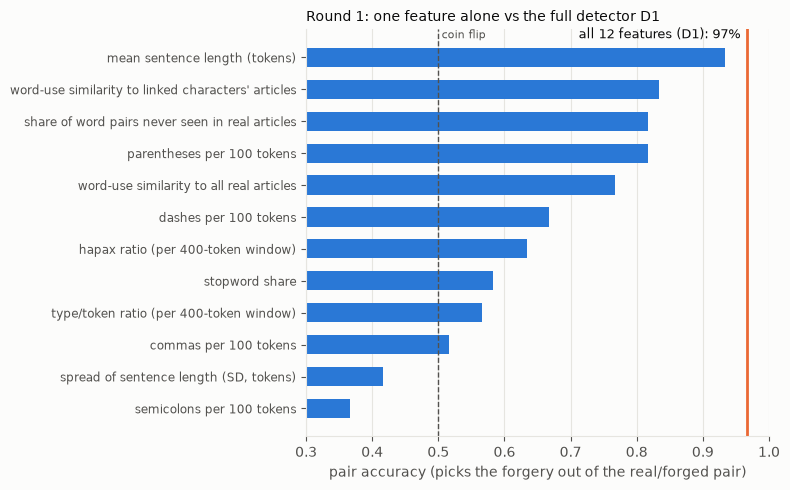

In [5]:
s = pd.DataFrame(res['single_feature']).T.sort_values('pair_accuracy')
fig, ax = plt.subplots(figsize=(8, 5))
y = np.arange(len(s))
ax.barh(y, s.pair_accuracy, color=REAL, height=0.6)
ax.axvline(0.5, color=MUTED, lw=1, ls='--'); ax.text(0.505, len(s) - 0.4, 'coin flip', color=MUTED, fontsize=8)
ax.axvline(cv['pair_accuracy'], color=FORGED, lw=2)
ax.text(cv['pair_accuracy'] - 0.01, len(s) - 0.4, f"all 12 features (D1): {cv['pair_accuracy']:.0%}", color=INK, fontsize=9, ha='right')
ax.set_yticks(y, [ts.FEATURE_LABELS[f] for f in s.index], fontsize=8.5)
ax.set_xlim(0.3, 1.0); ax.set_xlabel('pair accuracy (picks the forgery out of the real/forged pair)')
ax.set_title('Round 1: one feature alone vs the full detector D1', loc='left', fontsize=10)
ax.grid(axis='x', color=GRID, lw=0.8); ax.set_axisbelow(True)
fig.tight_layout()
for ext in ('png', 'svg'): fig.savefig(FIG / f'single_feature_round1.{ext}', dpi=150)
plt.show()

In [6]:
coef = pd.Series(res['coefficients']).rename(index=ts.FEATURE_LABELS)
print('Frozen D1 coefficients (standardized features; positive pushes towards "forged"):')
coef.round(2).to_frame('coefficient')

Frozen D1 coefficients (standardized features; positive pushes towards "forged"):


,coefficient
mean sentence length (tokens),2.60
"spread of sentence length (SD, tokens)",-1.84
parentheses per 100 tokens,0.64
hapax ratio (per 400-token window),0.60
share of word pairs never seen in real articles,-0.58
word-use similarity to all real articles,-0.54
stopword share,0.44
commas per 100 tokens,-0.38
semicolons per 100 tokens,0.33
word-use similarity to linked characters' articles,0.26


## 3. Memorization: is the forger copying Wikipedia?

Longest shared run of tokens and number of shared 8-grams between each forgery and (a) its own character's real page, (b) any real page. As a baseline, the same numbers for each real comparison text against the *other* 302 real pages: Wikipedia copying itself. *Distinctive* 8-grams leave out stock phrasing that appears in at least 10% of real pages (e.g. *appearing in american comic books published by marvel comics*).

In [7]:
mem = pd.read_csv(ROOT / 'outputs/memorization_round1.csv')
cols = ['own_longest_run', 'own_shared_8grams', 'own_distinctive_8grams', 'any_longest_run', 'any_shared_8grams', 'any_distinctive_8grams']
table = mem.groupby('doc')[cols].agg(['median', 'max']).T.unstack(level=0)
table

doc            forgery                                                                                                   real (vs other real pages)  \
       own_longest_run own_shared_8grams own_distinctive_8grams any_longest_run any_shared_8grams any_distinctive_8grams            own_longest_run   
median            15.0              10.5                    6.0            18.0              18.0                   12.0                        NaN   
max               33.0              36.0                   31.0            33.0              43.0                   34.0                        NaN   

doc                                                                                                       
       own_shared_8grams own_distinctive_8grams any_longest_run any_shared_8grams any_distinctive_8grams  
median               NaN                    NaN            15.0              17.0                   11.5  
max                  NaN                    NaN            46.0             108.0                  106.0

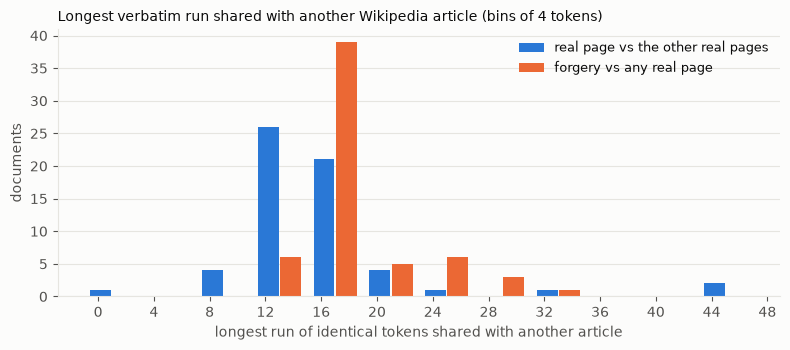

                   name  own_longest_run  own_distinctive_8grams
      Shuri (character)             33.0                    31.0
             Spider-Man             31.0                    24.0
Abomination (character)             30.0                    25.0
       Paladin (comics)             28.0                    15.0
         Rocket Raccoon             27.0                    21.0


In [8]:
fig, ax = plt.subplots(figsize=(8, 3.6))
bins = np.arange(0, 52, 4)
groups = [('real (vs other real pages)', REAL, 'real page vs the other real pages'), ('forgery', FORGED, 'forgery vs any real page')]
for k, (doc, col, lab) in enumerate(groups):
    h, _ = np.histogram(mem.loc[mem.doc == doc, 'any_longest_run'], bins=bins)
    ax.bar(bins[:-1] + 1 + (k - 0.5) * 1.6, h, width=1.5, color=col, label=lab)
ax.set_xticks(bins)
ax.set_xlabel('longest run of identical tokens shared with another article'); ax.set_ylabel('documents')
ax.legend(frameon=False, fontsize=9); ax.grid(axis='y', color=GRID, lw=0.8); ax.set_axisbelow(True)
ax.set_title('Longest verbatim run shared with another Wikipedia article (bins of 4 tokens)', loc='left', fontsize=10)
fig.tight_layout()
for ext in ('png', 'svg'): fig.savefig(FIG / f'memorization_round1.{ext}', dpi=150)
plt.show()
print(mem[mem.doc == 'forgery'].sort_values('own_longest_run', ascending=False)[['name', 'own_longest_run', 'own_distinctive_8grams']].head(5).to_string(index=False))

In [9]:
# What the longest copied run actually says, for the top three forgeries
from collections import defaultdict
arts = json.loads(config.ARTICLES_FILE.read_text())
load_forgery = importlib.import_module('03_features').load_forgery
def longest_run(a, b):
    idx = defaultdict(list)
    for j in range(len(b) - 7): idx[tuple(b[j:j+8])].append(j)
    best = (0, 0)
    for i in range(len(a) - 7):
        for j in idx.get(tuple(a[i:i+8]), []):
            k = 8
            while i + k < len(a) and j + k < len(b) and a[i+k] == b[j+k]: k += 1
            best = max(best, (k, i))
    return ' '.join(a[best[1]:best[1] + best[0]])
for nid in mem[mem.doc == 'forgery'].sort_values('own_longest_run', ascending=False).node_id.head(3):
    print(f"{arts[nid]['name']}:\n  {longest_run(ts.doc_tokens(load_forgery(1, nid)), ts.doc_tokens(arts[nid]['clean']))}\n")

Shuri (character):
  appearing in american comic books published by marvel comics created by writer reginald hudlin and artist john romita jr the character first appeared in black panther vol 4 2 may 2005 shuri is

Spider-Man:
  in american comic books published by marvel comics created by writer editor stan lee and artist steve ditko he first appeared in the anthology comic book amazing fantasy 15 august 1962

Abomination (character):
  character appearing in american comic books published by marvel comics created by writer stan lee and artist gil kane the character first appeared in tales to astonish 90 april 1967



## 4. Text inspection (required): read before believing any number

Below: the 5 forgeries D1 is most sure about, then the 5 documents it gets most wrong (any class), using **out-of-fold** probabilities (each document scored by a model that never saw that character). Word pairs that never occur in any *other* real article are wrapped in «guillemets». Real text is Wikipedia (CC BY-SA 4.0); forged text is **AI-generated**.

In [10]:
corpus = ts.RealCorpus(arts, ts.stopwords())
sample = {c['node_id']: c for c in json.loads(config.SAMPLE_FILE.read_text())['sample']}
def text_of(row):
    return sample[row.node_id]['comparison_text'] if row.label == 0 else load_forgery(1, row.node_id)
def show(row):
    kind = 'REAL (Wikipedia)' if row.label == 0 else 'FORGERY (AI-generated by Claude Fable 5.1)'
    f = r1[(r1.node_id == row.node_id) & (r1.label == row.label)].iloc[0]
    print('=' * 100)
    print(f"{row['name']} | {kind} | D1 P(forged) = {row.p_forged_oof:.2f} | mean sentence {f.sent_len_mean:.1f} tokens | "
          f"never-seen pairs {f.unseen_bigram_rate:.1%} | parentheses/100 {f.paren_rate:.2f}")
    print('=' * 100)
    print(corpus.highlight_unseen(text_of(row), row.node_id)); print()
p1 = pred[pred['round'].isin([0, 1])]
print('THE 5 FORGERIES D1 IS MOST SURE ABOUT\n')
for _, row in p1[p1.label == 1].sort_values('p_forged_oof', ascending=False).head(5).iterrows(): show(row)

THE 5 FORGERIES D1 IS MOST SURE ABOUT

Black Widow (Natasha Romanova) | FORGERY (AI-generated by Claude Fable 5.1) | D1 P(forged) = 1.00 | mean sentence 30.4 tokens | never-seen pairs 27.7% | parentheses/100 1.71
Black Widow (Natasha «Romanova) is» a superhero appearing in American comic books published by Marvel Comics. The character was created by editor Stan «Lee, scripter Don» Rico and artist Don Heck, and first appeared in Tales of «Suspense #52 (April 1964»). Introduced as a «Soviet intelligence» operative and an adversary of Iron Man, she «later defected» to the United «States, becoming» an agent of the espionage agency S.H.I.E.L.D. and «a longstanding member» of the Avengers. She has also been affiliated with the Champions, the Thunderbolts and the Secret Avengers.

«Natasha's real» name is usually given «as Natalia Alianovna Romanova, with» Natasha «Romanoff used» as «an anglicized form». She was trained from childhood in the Red Room, a «Soviet program that produced female as

In [11]:
print('THE 5 DOCUMENTS D1 GETS MOST WRONG\n')
wrong = p1.assign(err=(p1.label - p1.p_forged_oof).abs()).sort_values('err', ascending=False).head(5)
print(wrong[['name', 'label', 'p_forged_oof']].rename(columns={'label': 'truly forged?'}).to_string(index=False)); print()
for _, row in wrong.iterrows(): show(row)

THE 5 DOCUMENTS D1 GETS MOST WRONG

                          name  truly forged?  p_forged_oof
Black Widow (Natasha Romanova)              0      0.929427
                Sean and Chris              1      0.112374
             Ricochet (comics)              1      0.117727
       Abomination (character)              0      0.864158
                  Box (comics)              1      0.139699

Black Widow (Natasha Romanova) | REAL (Wikipedia) | D1 P(forged) = 0.93 | mean sentence 22.6 tokens | never-seen pairs 28.6% | parentheses/100 1.55
Black «Widow is» a superhero appearing in American comic books published by Marvel Comics. Created by editor Stan «Lee, scripter Don» Rico, and artist Don Heck, the character debuted as an enemy of Iron Man in Tales of «Suspense #52 (1964). She reformed» into a hero in The «Avengers #30 (1966») and her most well-«known design» was introduced in The Amazing Spider-Man #«86 (1970). Black Widow has» been the main character in several comic titles «since 

## 5. Feedback the forger would get in round 2

Computed by `04_detector.py` from D1, aggregated over all forgeries (never per character). Not used until round 2 is approved.

In [12]:
fb = json.loads((ROOT / 'outputs/feedback_round2.json').read_text())
print(f"caught {fb['caught']} of {fb['total']}\n"); print(fb['feature_table']); print('\nimpossible bigrams:', fb['impossible_bigrams'])

caught 54 of 60

- mean sentence length (tokens): real 20.08, forgeries 24.49
- parentheses per 100 tokens: real 0.61, forgeries 1.05
- share of word pairs never seen in real articles: real 32.1%, forgeries 28.0%
- hapax ratio (per 400-token window): real 0.40, forgeries 0.41
- dashes per 100 tokens: real 0.11, forgeries 0.36

impossible bigrams: "2011 2012", "mobile game", "period the", "crossover secret", "character headlined", "regular in", "supplied by", "paired her", "2010 by", "a working", "2011 by", "hulk's warbound", "that follow", "forearms and", "has generally"
